# Creating an XGBoost Forecast model
[📥 Download Notebook](https://github.com/Mosqlimate-project/mosqlimate-client/blob/main/docs/tutorials/xgb_model.ipynb)
 
In this notebook we will show how to create an XGBoost forecast model using the `mosqlient` package.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("API_KEY")

In [3]:
import pandas as pd
from datetime import date
from mosqlient.datastore import Infodengue
from mosqlient.forecast import ForecastXGB
from mosqlient.forecast.viz import (
    plot_training_model_loss,
    plot_model_comparison,
    plot_single_forecast,
)

Before applying the XGBoost model, it is necessary to load the data. In this example, we will use the dengue data in Rio de Janeiro city (geocode = 3304557). The model uses `casos` as the target and can use the available climate and epidemiological variables as predictors.

In [4]:
disease = 'dengue'
geocode = 3304557 
end_date = date.today().strftime('%Y-%m-%d')

df = Infodengue.get(api_key = api_key,
                    disease =  disease,
                    start = "2010-01-01",
                    end = end_date, 
                    geocode = geocode)

df = pd.DataFrame(df)
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'])

df = df[['data_iniSE', 'casos', 'tempmin', 'umidmin', 'Rt']]
df = df.set_index('data_iniSE')
df = df.resample('W-SUN').agg({
    'casos': 'sum',
    'tempmin': 'mean',
    'umidmin': 'mean',
    'Rt': 'mean',
})

df.head()

100%|██████████| 2/2 [00:02<00:00,  1.18s/requests]


,casos,tempmin,umidmin,Rt
data_iniSE,,,,
2010-01-03,30,25.142857,45.857143,0.0
2010-01-10,44,24.428571,40.857143,0.0
2010-01-17,46,23.857143,37.857143,0.0
2010-01-24,47,23.714286,42.857143,0.0
2010-01-31,68,25.142857,33.571429,0.0


The cell below creates the XGBoost forecast model. It uses previous observations as lag features, rolling statistics, calendar features and the supplied predictors. The model predicts four weekly steps at a time.


The target and predictor columns are passed explicitly. The date column remains separate so that the model can create calendar features.

### Define the model hyperparameters

These parameters control the input window, forecasting horizon and the size and regularization of the boosted-tree ensemble.

| Parameter | Description |
| --- | --- |
| `look_back` | Number of previous weeks used to create lag features. |
| `predict_n` | Number of future weeks predicted by each training row. |
| `n_estimators` | Maximum number of boosting trees. |
| `max_depth` | Maximum depth of each tree; larger values can overfit. |
| `learning_rate` | Contribution of each new tree. |
| `early_stopping_rounds` | Stops training when validation error stops improving. |
| `val_ratio` | Fraction of the final training rows reserved for validation. |
| `use_log` | Applies `log1p` to the target during training and reverses it in predictions. |

`casos` is the target. The other selected columns are predictors. At each prediction origin, the model uses lagged values and calendar information; future predictor values are carried forward from the last observation by the recursive forecast implementation.

In [5]:
columns = ['casos', 'tempmin', 'umidmin', 'Rt']
target_col = 'casos'
look_back = 4
predict_n = 4
n_estimators = 500
max_depth = 3
learning_rate = 0.03
use_log = True
early_stopping_rounds = 40
val_ratio = 0.15

In [6]:
m_xgb = ForecastXGB(
    df_data=df.reset_index(),
    columns=columns,
    date_col='data_iniSE',
    target_col=target_col,
    look_back=look_back,
    predict_n=predict_n,
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
)

m_xgb

### Train the model 

To train the model, define the initial date, the last date used for training and the end of the available evaluation data. Rows whose future targets cross `end_train_date` are excluded from training, so the validation and test periods remain chronologically separated.

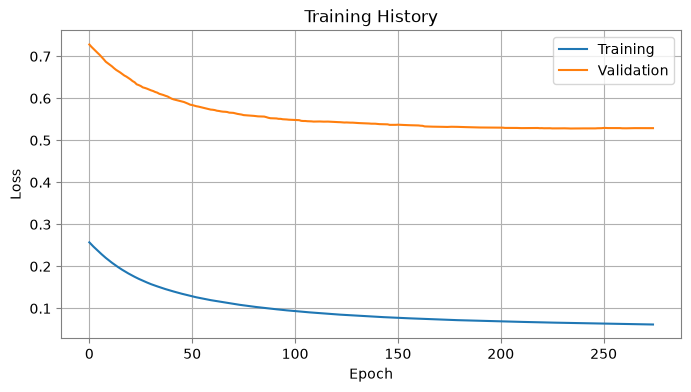

In [7]:
model, history = m_xgb.train(
    ini_train_date='2010-01-01',
    end_train_date='2021-12-31',
    end_date='2023-12-31',
    use_log=use_log,
    early_stopping_rounds=early_stopping_rounds,
    val_ratio=val_ratio,
)

_, ax = plot_training_model_loss(history)

#### Predictions in sample

Performance of the model on the training sample.

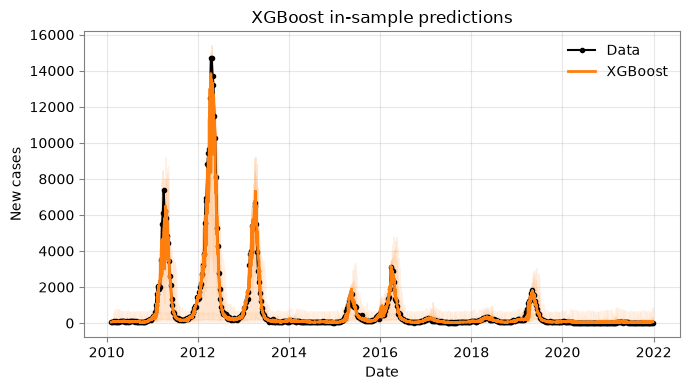

In [8]:
df_in_sample = m_xgb.predict_in_sample()

_, ax = plot_model_comparison(
    df_preds=df_in_sample,
    date_col='date',
    target_col='casos',
    label='XGBoost',
    title='XGBoost in-sample predictions',
    xlabel='Date',
    ylabel='New cases',
)

In [9]:
df_in_sample.head()

,last_date,date,horizon,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos
0,2010-01-31,2010-02-07,1,30.939365,37.578457,41.748276,46.856720,55.945393,58.591671,79.186531,96.482445,202.849960,56
1,2010-01-31,2010-02-14,2,28.098392,33.144264,43.164242,57.754799,66.045464,66.045464,100.937080,140.507614,289.369995,66
2,2010-01-31,2010-02-21,3,35.293495,35.577503,43.702152,62.090778,74.471947,74.698898,110.123993,141.688553,270.801758,74
3,2010-01-31,2010-02-28,4,30.449051,40.310799,50.549244,56.242519,82.856079,95.140686,153.534836,214.674896,618.669250,95
4,2010-02-07,2010-02-14,1,39.973759,45.871788,54.756538,65.971970,68.312157,75.161728,94.870956,110.499092,205.085846,66


#### Predictions out of sample

The out-of-sample performance starts after the last date used to train the model.

The returned dataframe contains the observed values and the predictions generated for the evaluation period.

,last_date,date,horizon,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos
0,2022-01-02,2022-01-09,1,21.703991,21.703991,24.204142,37.488514,44.149426,71.386177,89.140968,101.438095,210.326141,14
1,2022-01-02,2022-01-16,2,20.734686,27.116541,30.749575,43.915283,55.583881,79.905548,96.494301,133.476456,294.590851,22
2,2022-01-02,2022-01-23,3,25.242750,28.826141,28.826141,47.271187,54.402493,102.119850,124.026001,130.913055,237.401810,19
3,2022-01-02,2022-01-30,4,26.547749,28.117338,39.515572,43.883961,82.798035,98.997574,136.976456,205.316132,769.073730,31
4,2022-01-09,2022-01-16,1,29.423346,29.423346,34.125633,39.752964,46.184174,66.093590,105.025398,140.919342,241.141312,22


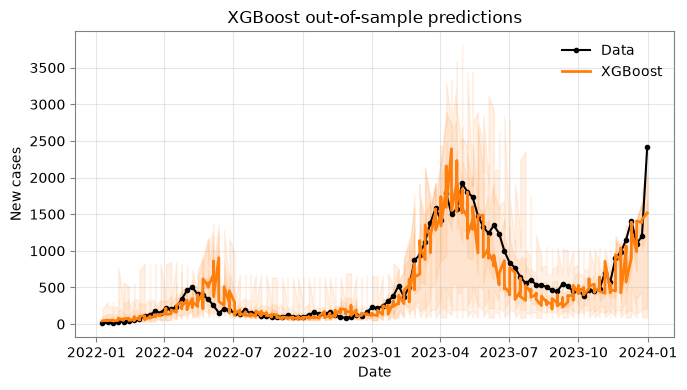

In [10]:
df_out = m_xgb.predict_out_of_sample()

_, ax = plot_model_comparison(
    df_preds=df_out,
    date_col='date',
    target_col='casos',
    label='XGBoost',
    title='XGBoost out-of-sample predictions',
    xlabel='Date',
    ylabel='New cases',
)

df_out.head()

### Forecast 

To forecast beyond the available observations, the model must be trained first. The forecast starts after the last observed date. 

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon
0,2026-08-02,2026-08-09,125.991119,135.941223,141.646988,150.845764,178.859299,195.357468,211.971802,250.301590,321.224518,1
1,2026-08-02,2026-08-16,102.547447,112.938263,112.938263,113.126831,158.253616,171.807663,237.779419,253.986267,322.181915,2
2,2026-08-02,2026-08-23,109.197250,111.268562,111.268562,120.073486,139.982468,188.552338,259.534821,259.534821,335.019989,3
3,2026-08-02,2026-08-30,90.955002,90.955002,90.955002,103.294212,108.099861,169.953613,247.135422,298.623749,373.435425,4


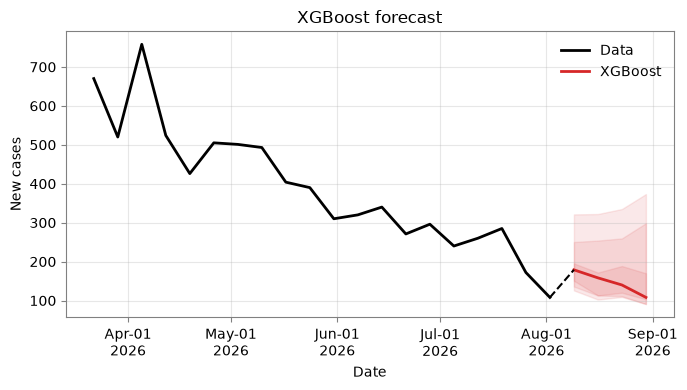

In [11]:
model, history = m_xgb.train(
    ini_train_date='2010-01-01',
    end_train_date=end_date,
    end_date=end_date,
)

forecast_end_date = (pd.Timestamp(end_date) + pd.Timedelta(weeks=8)).strftime('%Y-%m-%d')
df_for = m_xgb.forecast(end_date=forecast_end_date)

df_train = (
    m_xgb.df_model.reset_index()
    .rename(columns={'data_iniSE': 'date', 'casos': 'data'})
)
_, ax = plot_single_forecast(
    df_for=df_for,
    df_train=df_train,
    target_col='data',
    date_col='date',
    title='XGBoost forecast',
    label='XGBoost',
    xlabel='Date',
    ylabel='New cases',
)

df_for.head()